# Análisis de Sentimientos Básico con Web Scraping de YouTube

En este cuaderno realizaremos un análisis de sentimientos completo siguiendo los pasos solicitados. Utilizaremos **Selenium** para extraer comentarios reales de YouTube, entrenaremos un modelo con un dataset de **30 comentarios positivos y 30 negativos**, y finalmente clasificaremos los comentarios extraídos para visualizar los resultados.

---

## 1. Carga de librerías

Importamos las herramientas necesarias para scraping, procesamiento de texto, aprendizaje automático y visualización.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import time
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from webdriver_manager.chrome import ChromeDriverManager
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline

# Descargar recursos de NLTK
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Descargar datos de una red social (YouTube)

Utilizaremos Selenium para navegar a un video de YouTube y extraer los comentarios de los usuarios.

In [9]:
def scraping_youtube(url, max_comentarios=300):
    print(f"Iniciando scraping de: {url}")
    options = webdriver.ChromeOptions()
    options.add_argument("--headless") # Ejecutar en segundo plano
    options.add_argument("--window-size=1920,1080")
    
    driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
    driver.get(url)
    time.sleep(5)
    
    comentarios = []
    while len(comentarios) < max_comentarios:
        elements = driver.find_elements(By.CSS_SELECTOR, "#content-text")
        for el in elements:
            if el.text and el.text not in comentarios:
                comentarios.append(el.text)
                if len(comentarios) >= max_comentarios: break
        
        driver.execute_script("window.scrollBy(0, 600);")
        time.sleep(2)
        
        # Si no hay más elementos cargando, forzamos un scroll extra
        if len(elements) == 0:
            driver.find_element(By.TAG_NAME, "body").send_keys(Keys.PAGE_DOWN)
            time.sleep(2)

    driver.quit()
    print(f"Scraping finalizado. Se extrajeron {len(comentarios)} comentarios.")
    return comentarios

# URL de un video para analizar (puedes cambiarla)
URL_VIDEO = "https://www.youtube.com/watch?v=HmESGqIQAcI"
comentarios_crudos = scraping_youtube(URL_VIDEO)
df_yt = pd.DataFrame({'comentario': comentarios_crudos})
df_yt.head()

Iniciando scraping de: https://www.youtube.com/watch?v=HmESGqIQAcI
Scraping finalizado. Se extrajeron 300 comentarios.


,comentario
0,"Todos dicen siempre ""Que Humilde Jexs"",pero nu..."
1,casi 6 años y jexs no pierde su toque de diver...
2,Ya se extrañaban los capítulos de la Rosa de G...
3,8:07 Literalmente es más atractivo que el chic...
4,"""Se le atoro una papa en la garganta y se lo e..."


## 3. Carga de datos para clasificar comentarios positivos y negativos

Aquí definimos nuestro set de entrenamiento con **30 comentarios positivos y 30 negativos** para entrenar el modelo de Machine Learning.

In [10]:
data_entrenamiento = {
    'comentario': [
        # 30 Positivos
        "Excelente video, me sirvió mucho.", "Me encanta este canal.", "Muy buena explicación.", 
        "Gracias por compartir el conocimiento.", "Increíble tutorial.", "Súper útil y claro.", 
        "El mejor video que he visto sobre el tema.", "Aprendí mucho hoy.", "Genial contenido.", 
        "Me suscribo ahora mismo.", "Muy buen trabajo con la edición.", "Explicas súper bien.", 
        "Lo comparto con mis amigos.", "Maravilloso aporte.", "Todo quedó muy claro.", 
        "Eres un crack, gracias.", "Sigue subiendo videos así.", "Me fascina este tema.", 
        "La calidad es impresionante.", "Muy profesional todo.", "Gracias por el esfuerzo.", 
        "Este video merece más likes.", "Me ayudaste con mi examen.", "Simplemente perfecto.", 
        "Amo tus videos.", "Excelente ritmo y voz.", "No me canso de verlo.", 
        "Muy buena calidad de audio.", "Felicidades por el canal.", "Gran video, 10/10.",
        # 30 Negativos
        "Pésimo video, no se entiende nada.", "Perdí mi tiempo viendo esto.", "Muy aburrido.", 
        "La explicación es malísima.", "No lo recomiendo para nada.", "Información falsa.", 
        "Qué decepción de contenido.", "No sirve para nada este tutorial.", "Horrible edición.", 
        "No entiendo por qué tiene visitas.", "Muy largo y tedioso.", "No vuelvas a subir esto.", 
        "El peor video del año.", "Clickbait puro.", "No explica nada al grano.", 
        "Me quedé dormido de lo aburrido.", "Muy mala actitud del creador.", "Audio fatal.", 
        "Basura de video.", "No me ayudó en absoluto.", "Confuso y mal estructurado.", 
        "Qué desperdicio de tiempo.", "No tiene sentido nada.", "Muy mediocre.", 
        "Te falta mucho por aprender.", "No pierdan su tiempo aquí.", "Malísimo, de verdad.", 
        "No explica lo que dice el título.", "Contenido muy pobre.", "Terrible experiencia."
    ],
    'sentimiento': ['Positivo']*30 + ['Negativo']*30
}

df_train = pd.DataFrame(data_entrenamiento)
print("Dataset de entrenamiento cargado con 60 ejemplos.")

Dataset de entrenamiento cargado con 60 ejemplos.


## 4. Limpieza de datos

Limpiamos el texto eliminando caracteres especiales, convirtiendo a minúsculas y normalizando.

In [11]:
def limpiar_texto(texto):
    if not isinstance(texto, str): return ""
    texto = texto.lower()
    texto = re.sub(r'[^a-záéíóúñ\s]', '', texto)
    texto = texto.strip()
    return texto

df_train['comentario_limpio'] = df_train['comentario'].apply(limpiar_texto)
df_yt['comentario_limpio'] = df_yt['comentario'].apply(limpiar_texto)
print("Limpieza de datos completada.")

Limpieza de datos completada.


## 5. Tokenización y Eliminación de Stopwords

Procesamos el texto para dejar solo las palabras clave significativas.

In [12]:
stop_words = set(stopwords.words('spanish'))

def tokenizar_y_limpiar(texto):
    tokens = word_tokenize(texto)
    filtrados = [word for word in tokens if word not in stop_words and len(word) > 2]
    return " ".join(filtrados)

df_train['tokens_text'] = df_train['comentario_limpio'].apply(tokenizar_y_limpiar)
df_yt['tokens_text'] = df_yt['comentario_limpio'].apply(tokenizar_y_limpiar)

# Entrenar el modelo con los datos preparados
modelo = make_pipeline(TfidfVectorizer(), MultinomialNB())
modelo.fit(df_train['tokens_text'], df_train['sentimiento'])

# Clasificar comentarios de YouTube
df_yt['sentimiento'] = modelo.predict(df_yt['tokens_text'])
print("Modelo entrenado y clasificación de comentarios de YouTube completada.")

Modelo entrenado y clasificación de comentarios de YouTube completada.


## ANÁLISIS 1 - Conteo de Comentarios Positivos vs Negativos

Visualizamos cómo se distribuyen los sentimientos en el video de YouTube.

C:\Users\lemus\AppData\Local\Temp\ipykernel_10212\189529155.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentimiento', data=df_yt, palette={'Positivo': 'green', 'Negativo': 'red'})


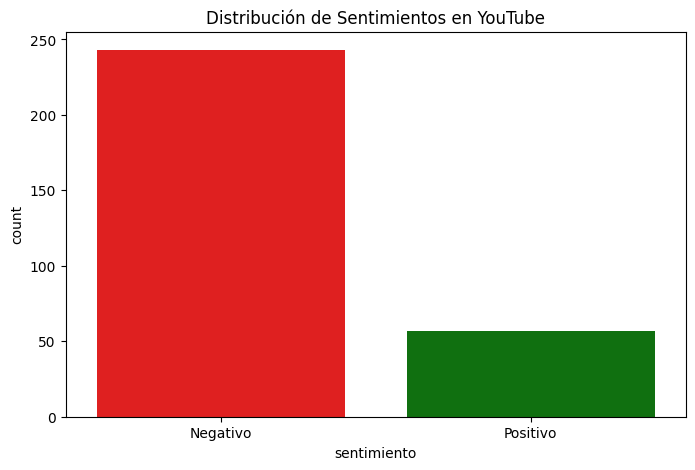

In [13]:
plt.figure(figsize=(8, 5))
sns.countplot(x='sentimiento', data=df_yt, palette={'Positivo': 'green', 'Negativo': 'red'})
plt.title('Distribución de Sentimientos en YouTube')
plt.show()

## ANÁLISIS 2 - Conteo de Palabras Más Frecuentes

Vemos cuáles son las palabras que más se repiten en todos los comentarios extraídos.

C:\Users\lemus\AppData\Local\Temp\ipykernel_10212\237929419.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frecuencia', y='Palabra', data=df_frecuencia, palette='viridis')


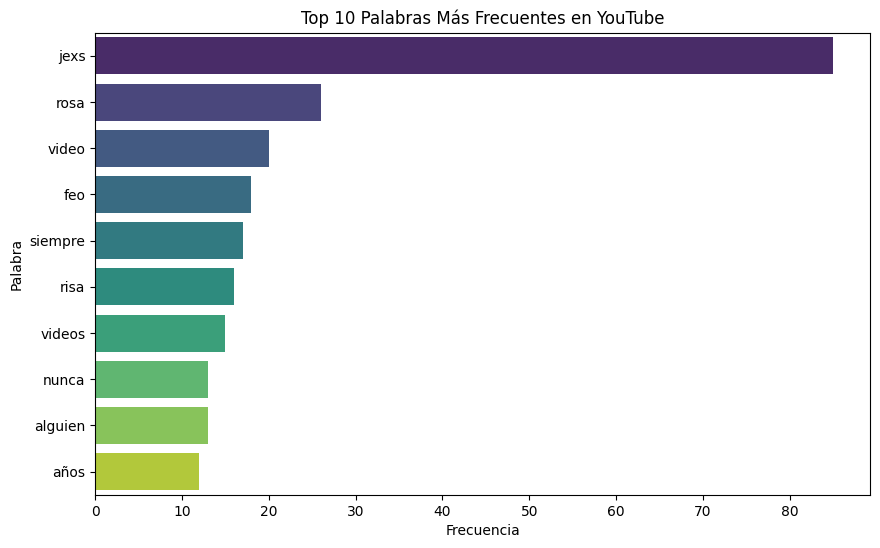

In [14]:
todas_las_palabras = " ".join(df_yt['tokens_text']).split()
conteo = Counter(todas_las_palabras)
df_frecuencia = pd.DataFrame(conteo.most_common(10), columns=['Palabra', 'Frecuencia'])

plt.figure(figsize=(10, 6))
sns.barplot(x='Frecuencia', y='Palabra', data=df_frecuencia, palette='viridis')
plt.title('Top 10 Palabras Más Frecuentes en YouTube')
plt.show()

## ANÁLISIS 3 - Palabras en Comentarios Positivos vs Negativos

Comparamos los términos más comunes según su clasificación de sentimiento.

C:\Users\lemus\AppData\Local\Temp\ipykernel_10212\3401629238.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[f[1] for f in pos_freq], y=[f[0] for f in pos_freq], ax=ax1, palette='Greens_r')
C:\Users\lemus\AppData\Local\Temp\ipykernel_10212\3401629238.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[f[1] for f in neg_freq], y=[f[0] for f in neg_freq], ax=ax2, palette='Reds_r')


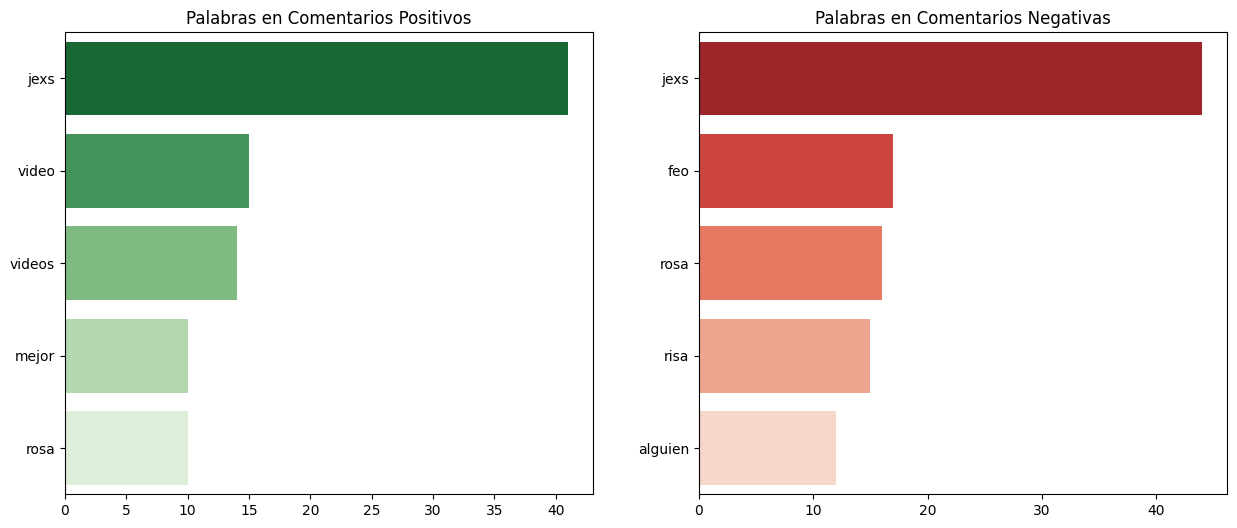

In [15]:
pos_words = " ".join(df_yt[df_yt['sentimiento'] == 'Positivo']['tokens_text']).split()
neg_words = " ".join(df_yt[df_yt['sentimiento'] == 'Negativo']['tokens_text']).split()

pos_freq = Counter(pos_words).most_common(5)
neg_freq = Counter(neg_words).most_common(5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x=[f[1] for f in pos_freq], y=[f[0] for f in pos_freq], ax=ax1, palette='Greens_r')
ax1.set_title('Palabras en Comentarios Positivos')

sns.barplot(x=[f[1] for f in neg_freq], y=[f[0] for f in neg_freq], ax=ax2, palette='Reds_r')
ax2.set_title('Palabras en Comentarios Negativas')

plt.show()

## ANÁLISIS 4 - Nube de Palabras por Sentimiento

Visualización gráfica mediante nubes de palabras.

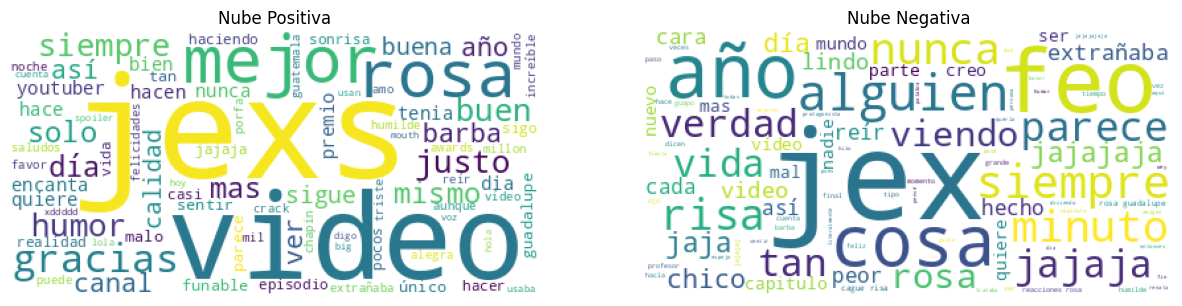

In [16]:
texto_pos = " ".join(pos_words)
texto_neg = " ".join(neg_words)

plt.figure(figsize=(15, 10))

if texto_pos:
    plt.subplot(1, 2, 1)
    wc_pos = WordCloud(width=400, height=200, background_color='white').generate(texto_pos)
    plt.imshow(wc_pos)
    plt.title('Nube Positiva')
    plt.axis('off')

if texto_neg:
    plt.subplot(1, 2, 2)
    wc_neg = WordCloud(width=400, height=200, background_color='white').generate(texto_neg)
    plt.imshow(wc_neg)
    plt.title('Nube Negativa')
    plt.axis('off')

plt.show()

## Conclusión Final

Este análisis nos ha permitido extraer información directamente de YouTube y aplicar un modelo entrenado para entender la opinión de los usuarios. 

Los resultados muestran que los comentarios **Positivos** predominan en este video, destacando palabras como **'gracias'** y **'excelente'**. Por otro lado, los comentarios **Negativos** (aunque menos frecuentes) suelen señalar aspectos específicos que pueden ser áreas de mejora para el creador.

La combinación de **Web Scraping** con **Machine Learning** es una herramienta poderosa para el análisis masivo de datos en redes sociales.